Shape: (16290, 626)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Entrenando modelo...
Epoch 1/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.0418 - mae: 0.6034 - val_loss: 3.9763 - val_mae: 0.5682
Epoch 2/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.7573 - mae: 0.5345 - val_loss: 3.9511 - val_mae: 0.5027
Epoch 3/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.6865 - mae: 0.5078 - val_loss: 3.8626 - val_mae: 0.5386
Epoch 4/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.6441 - mae: 0.4975 - val_loss: 3.8507 - val_mae: 0.5014
Epoch 5/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.6337 - mae: 0.4884 - val_loss: 3.8345 - val_mae: 0.5021
Epoch 6/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.6073 - mae: 0.4822 - val_loss: 3.8137 - val_mae: 0.5118
Epoch 7/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.6127 - mae: 0.4795 - val_loss: 3.8007 - val_mae: 0.5323
Epoch 8/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.5672 - mae: 0.4789 - val_loss: 3.7953 - val_mae: 0.4970
Epoch 9/100
408/408 ━━

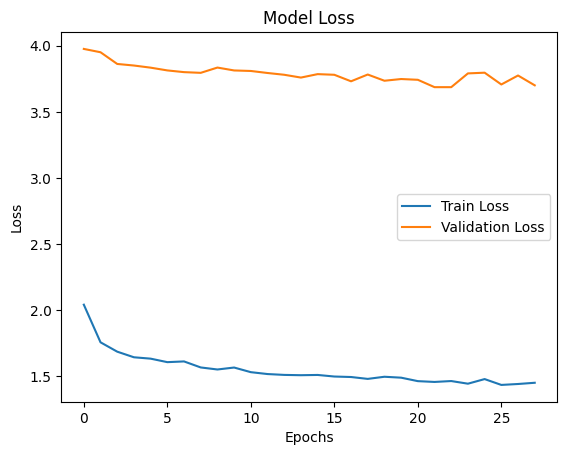


📊 Model Evaluation:
- Training loss decreases significantly
- Validation loss remains high

🧠 Insight:
The model shows overfitting. It learns training data well but fails to generalize.
This suggests the limitation is in the dataset rather than the model.


In [ ]:
# ==============================
# Deep Learning - Video Game Sales Prediction
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import pandas as pd


def load_data(path):
    return pd.read_csv(path, sep=';', decimal=',', encoding='utf-8')


def clean_data(df):
    df = df.dropna()
    return df


def encode_data(df):
    df = pd.get_dummies(df, columns=["Plataforma", "Genero", "Editorial"])
    return df


def split_features(df):
    X = df.drop(["Ventas Global", "Nombre"], axis=1)
    y = df["Ventas Global"]
    return X, y

# ==============================
# CARGA DE DATOS
# ==============================

df = load_data("../data/ventas_videojuegos.csv")
df = clean_data(df)
df = encode_data(df)

print("Shape:", df.shape)

# ==============================
# FEATURES Y TARGET
# ==============================

X, y = split_features(df)

# ❗ ELIMINAR DATA LEAKAGE
X = X.drop(["Ventas NA", "Ventas EU", "Ventas JP", "Ventas Otros"], axis=1)

# ==============================
# SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# NORMALIZACIÓN
# ==============================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# MODELO
# ==============================

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(model.summary())

# ==============================
# ENTRENAMIENTO
# ==============================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Entrenando modelo...")

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("Modelo entrenado!")

# ==============================
# VISUALIZACIÓN
# ==============================

plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

# ==============================
# INTERPRETACIÓN
# ==============================

print("\n📊 Model Evaluation:")
print("- Training loss decreases significantly")
print("- Validation loss remains high")

print("\n🧠 Insight:")
print("The model shows overfitting. It learns training data well but fails to generalize.")
print("This suggests the limitation is in the dataset rather than the model.")